# Actividad 13

-  1 Obtenga el siguiente dataframe “Medical Insurance Cost Prediction” de 
https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction

In [1]:
# Ejercicio 1 — Setup e importación del dataset desde Kaggle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import kagglehub
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='tab10')

# ── Descarga del dataset desde Kaggle ────────────────────────────
path = kagglehub.dataset_download('mohankrishnathalla/medical-insurance-cost-prediction')
print(f"Dataset descargado en: {path}")

# ── Listar archivos disponibles ───────────────────────────────────
archivos = os.listdir(path)
print(f"Archivos disponibles: {archivos}")

# ── Cargar el CSV ─────────────────────────────────────────────────
csv_files = [f for f in archivos if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))
print(f"\nArchivo cargado: {csv_files[0]}")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")


Using Colab cache for faster access to the 'medical-insurance-cost-prediction' dataset.
Dataset descargado en: /kaggle/input/medical-insurance-cost-prediction
Archivos disponibles: ['medical_insurance.csv']

Archivo cargado: medical_insurance.csv
Dimensiones: 100,000 filas × 54 columnas

Columnas: ['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_diseas

In [2]:
# Exploración inicial del dataset

print("=== Tipos de datos ===")
print(df.dtypes)
print(f"\n=== Valores nulos ===")
print(df.isnull().sum())
print(f"\n=== Resumen estadístico ===")
df.describe()


=== Tipos de datos ===
person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
co

,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000


- 2 Mostrar por pantalla los siguientes gráficos pedidos:

- 2 A) Boxplot de la distribución del ingreso por región que permita observar medidas claves

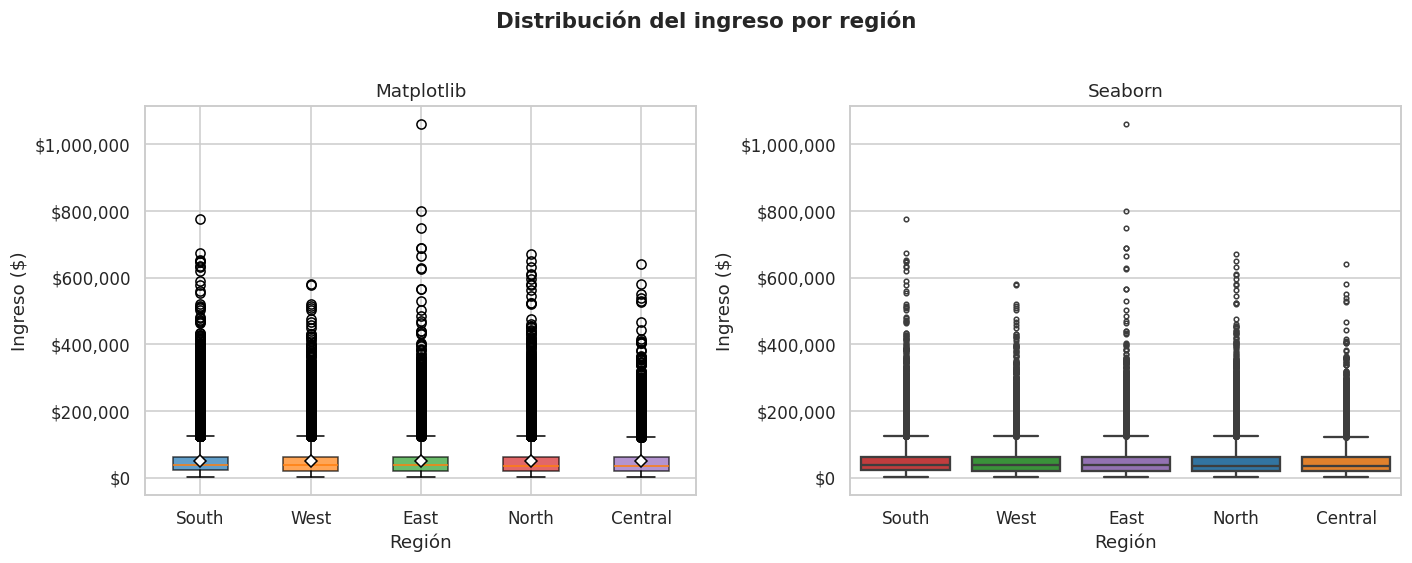

=== Medidas clave del ingreso por región ===

             N  Minimo       Q1  Mediana    Media       Q3     Maximo
region                                                               
South    28029  1100.0  21300.0  36500.0  50018.0  62200.0   774500.0
West     17879  1100.0  21100.0  36300.0  49660.0  62350.0   580400.0
East     19984  1900.0  21100.0  36300.0  50074.0  62700.0  1061800.0
North    22027  1600.0  21100.0  36100.0  50123.0  62000.0   670300.0
Central  12081  1700.0  21100.0  35800.0  49070.0  61400.0   641600.0


In [3]:
# 2A — Boxplot de la distribución del ingreso por región

# Verificar nombres exactos de las columnas relevantes
col_ingreso = 'income'
col_region  = 'region'

# Ordenar regiones por mediana de ingreso (de mayor a menor) para facilitar la lectura
orden_regiones = (
    df.groupby(col_region)[col_ingreso]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribución del ingreso por región', fontsize=14, fontweight='bold', y=1.02)

# ── 🔵 Matplotlib ──────────────────────────────────────────────────
datos_box = [df[df[col_region] == r][col_ingreso].dropna().values for r in orden_regiones]

bp = axes[0].boxplot(datos_box, labels=orden_regiones, patch_artist=True,
                     showmeans=True,
                     meanprops=dict(marker='D', markerfacecolor='white',
                                    markeredgecolor='black', markersize=6))

colores = sns.color_palette('tab10', len(orden_regiones))
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title('Matplotlib')
axes[0].set_xlabel('Región')
axes[0].set_ylabel('Ingreso ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# ── 🟠 Seaborn ─────────────────────────────────────────────────────
sns.boxplot(data=df, x=col_region, y=col_ingreso,
            order=orden_regiones,
            hue=col_region, legend=False,
            linewidth=1.5, fliersize=3,
            ax=axes[1])

axes[1].set_title('Seaborn')
axes[1].set_xlabel('Región')
axes[1].set_ylabel('Ingreso ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# ── Medidas clave por región ────────────────────────────────────────
print("=== Medidas clave del ingreso por región ===\n")
print(df.groupby(col_region)[col_ingreso]
      .agg(N='count', Minimo='min', Q1=lambda x: x.quantile(0.25),
           Mediana='median', Media='mean',
           Q3=lambda x: x.quantile(0.75), Maximo='max')
      .round(0)
      .sort_values('Mediana', ascending=False)
      .to_string())


  - 2 B) Gráficos de barras para las variables categóricas

Variables categóricas encontradas: ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']



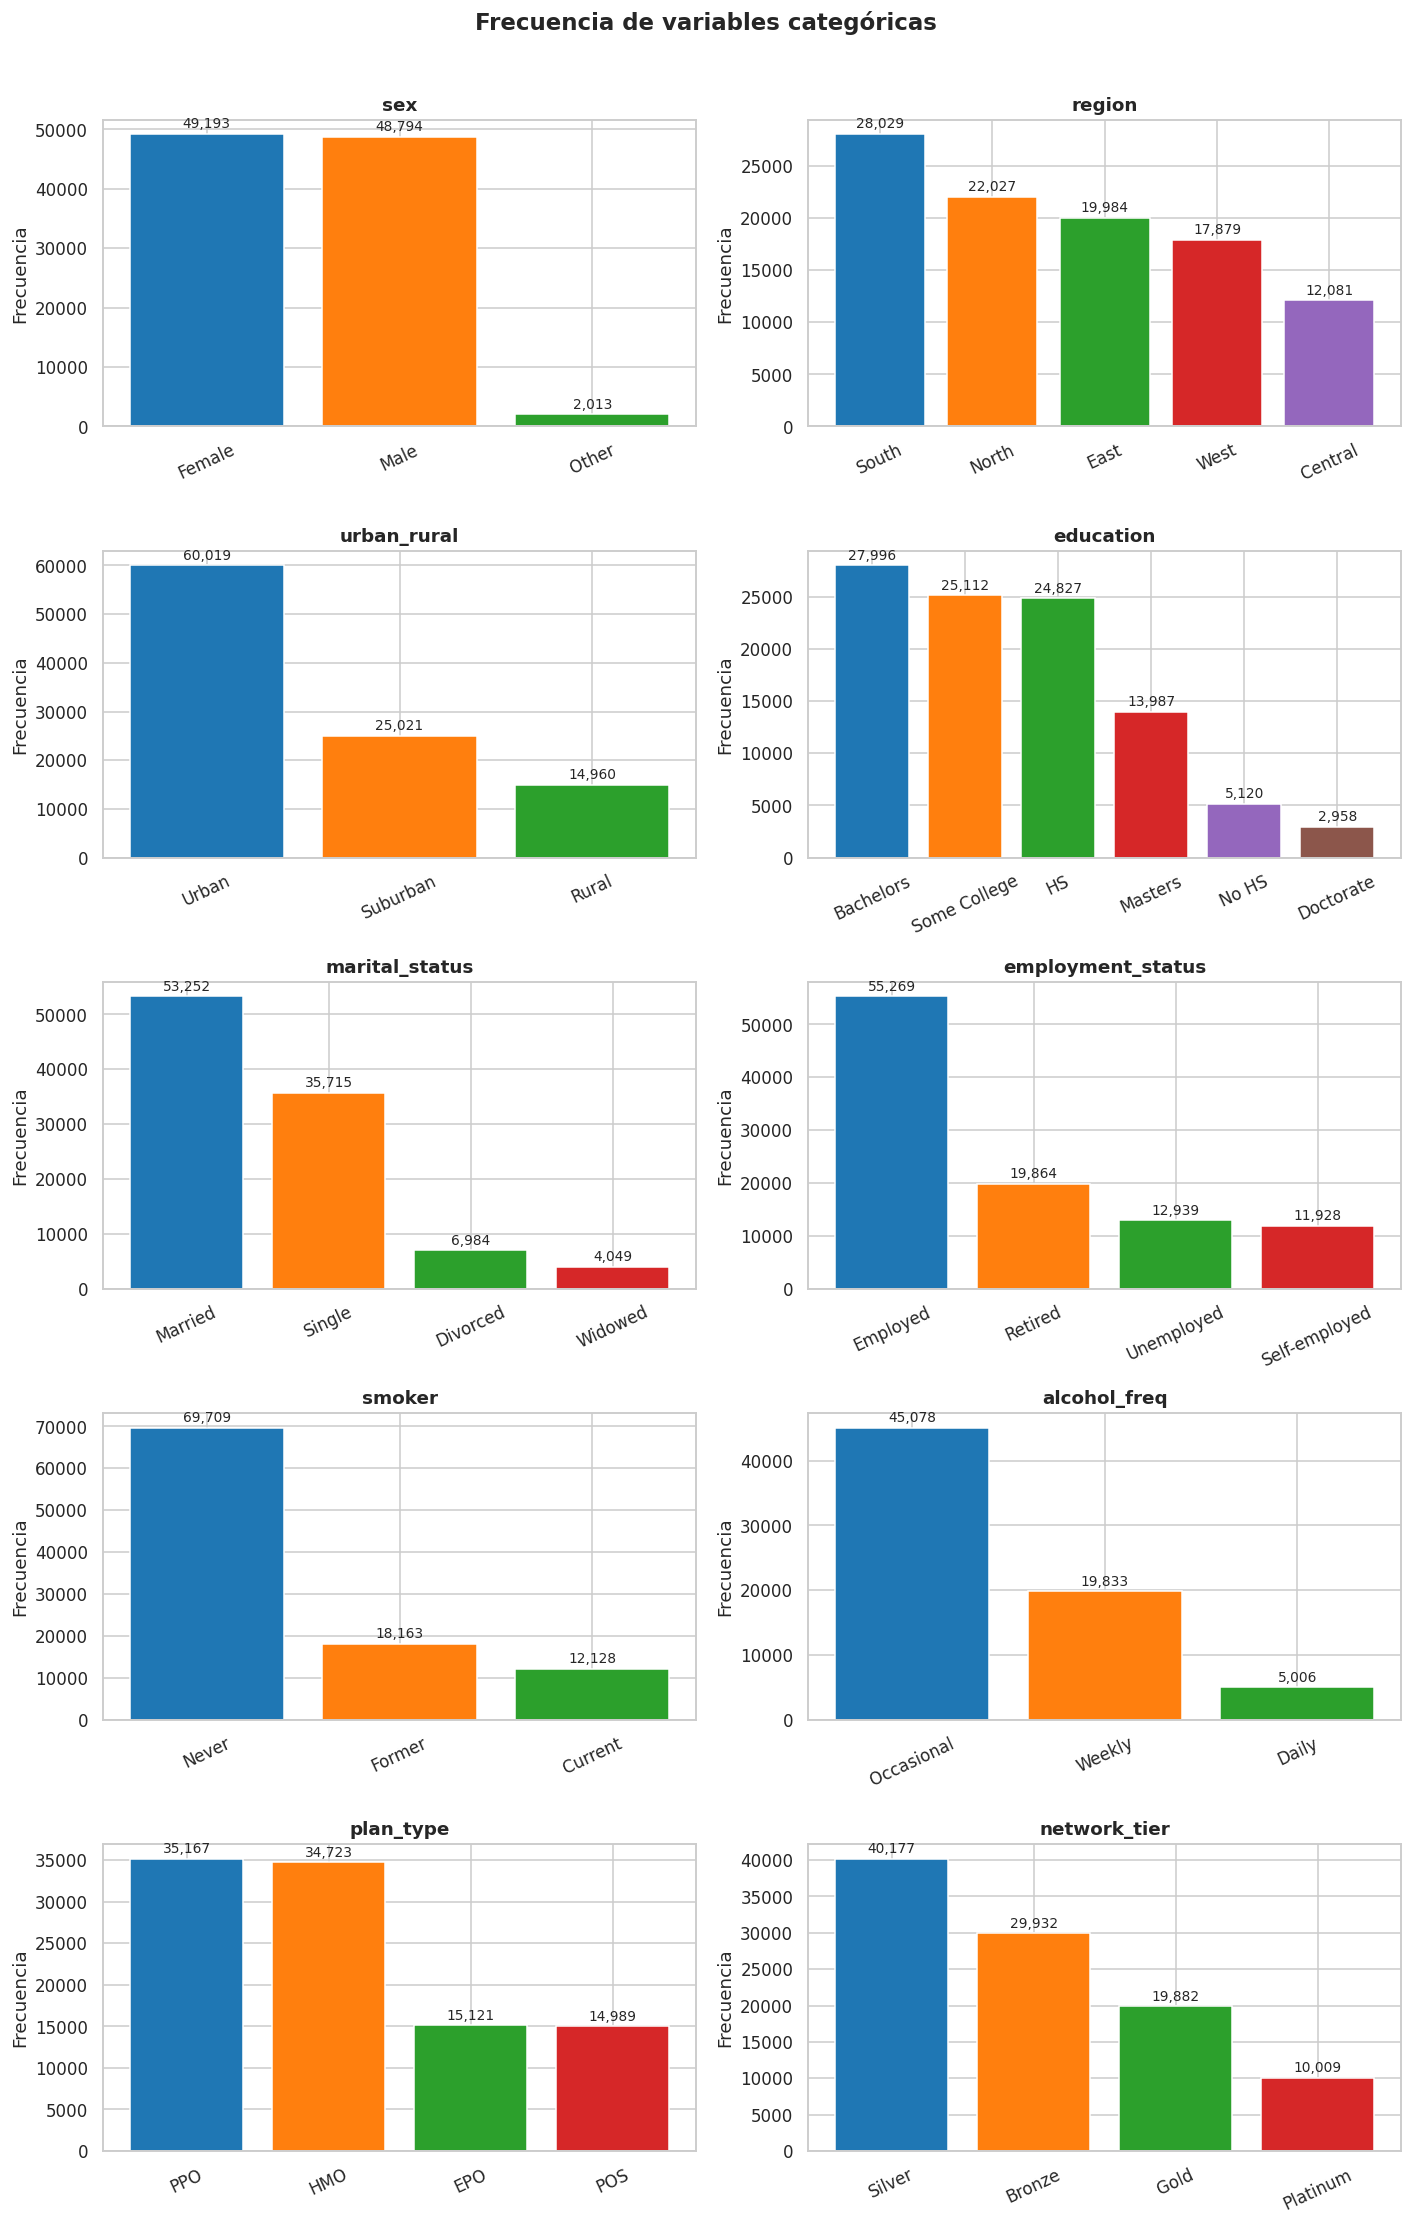


=== Frecuencia y porcentaje por variable categórica ===

── sex ──────────────────────────
        Frecuencia     %
sex                     
Female       49193  49.2
Male         48794  48.8
Other         2013   2.0

── region ──────────────────────────
         Frecuencia     %
region                   
South         28029  28.0
North         22027  22.0
East          19984  20.0
West          17879  17.9
Central       12081  12.1

── urban_rural ──────────────────────────
             Frecuencia     %
urban_rural                  
Urban             60019  60.0
Suburban          25021  25.0
Rural             14960  15.0

── education ──────────────────────────
              Frecuencia     %
education                     
Bachelors          27996  28.0
Some College       25112  25.1
HS                 24827  24.8
Masters            13987  14.0
No HS               5120   5.1
Doctorate           2958   3.0

── marital_status ──────────────────────────
                Frecuencia     %
ma

In [4]:
# 2B — Gráficos de barras para las variables categóricas

# Detectar automáticamente las columnas categóricas (object o bool)
cols_cat = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Variables categóricas encontradas: {cols_cat}\n")

n_cols = 2
n_rows = -(-len(cols_cat) // n_cols)   # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, n_rows * 4))
fig.suptitle('Frecuencia de variables categóricas', fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

paleta = sns.color_palette('tab10')

for i, col in enumerate(cols_cat):
    conteo = df[col].value_counts().sort_values(ascending=False)

    bars = axes[i].bar(conteo.index.astype(str), conteo.values,
                       color=paleta[:len(conteo)], edgecolor='white')

    # Etiquetas de valor sobre cada barra
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2, h + conteo.max() * 0.01,
                     f'{int(h):,}', ha='center', va='bottom', fontsize=9)

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=25)

# Ocultar paneles sobrantes si las columnas son impares
for j in range(len(cols_cat), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# ── Tabla de frecuencias y porcentajes ───────────────────────────
print("\n=== Frecuencia y porcentaje por variable categórica ===\n")
for col in cols_cat:
    conteo = df[col].value_counts()
    pct    = df[col].value_counts(normalize=True).mul(100).round(1)
    tabla  = pd.concat([conteo, pct], axis=1)
    tabla.columns = ['Frecuencia', '%']
    print(f"── {col} ──────────────────────────")
    print(tabla.to_string())
    print()


  - 2 C) Scatterplot usando las variables risk_score e ingreso clasificados por género

Columnas usadas → x: 'risk_score' | y: 'income' | color: 'sex'


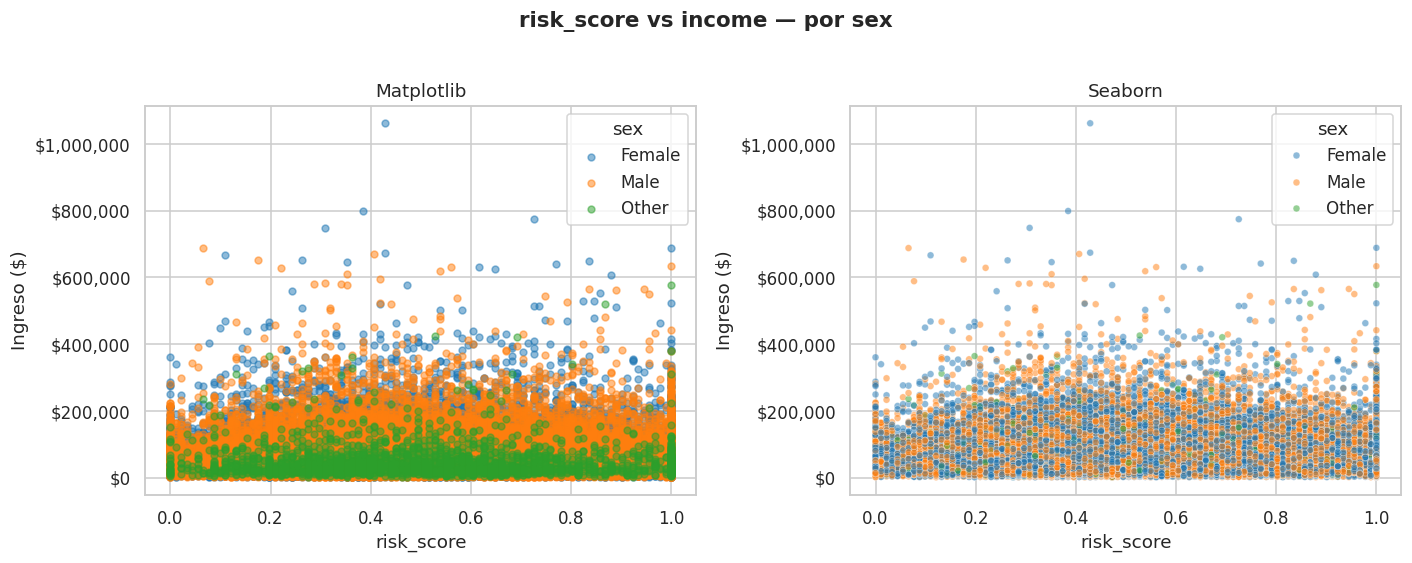


=== Correlación risk_score vs income por sex ===

sex
Female    0.0111
Male      0.0061
Other    -0.0015


In [5]:
# 2C — Scatterplot de risk_score vs ingreso clasificado por género

# Detección robusta del nombre de columna real
def encontrar_col(df, candidatos):
    for c in candidatos:
        if c in df.columns:
            return c
    raise KeyError(f"Ninguna de estas columnas existe: {candidatos}. Columnas disponibles: {list(df.columns)}")

col_x      = encontrar_col(df, ['risk_score', 'risk score', 'RiskScore'])
col_y      = encontrar_col(df, ['income', 'charges', 'Income'])
col_genero = encontrar_col(df, ['gender', 'sex', 'Gender', 'Sex'])

print(f"Columnas usadas → x: '{col_x}' | y: '{col_y}' | color: '{col_genero}'")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{col_x} vs {col_y} — por {col_genero}',
             fontsize=14, fontweight='bold', y=1.02)

generos = df[col_genero].dropna().unique()
colores = sns.color_palette('tab10', len(generos))

# ── 🔵 Matplotlib ──────────────────────────────────────────────────
for genero, color in zip(generos, colores):
    datos = df[df[col_genero] == genero]
    axes[0].scatter(datos[col_x], datos[col_y],
                    label=genero, color=color, alpha=0.5, s=20)

axes[0].set_title('Matplotlib')
axes[0].set_xlabel(col_x)
axes[0].set_ylabel('Ingreso ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(title=col_genero)

# ── 🟠 Seaborn ─────────────────────────────────────────────────────
sns.scatterplot(data=df, x=col_x, y=col_y,
                hue=col_genero, alpha=0.5, s=20,
                ax=axes[1])

axes[1].set_title('Seaborn')
axes[1].set_xlabel(col_x)
axes[1].set_ylabel('Ingreso ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend(title=col_genero)

plt.tight_layout()
plt.show()

# ── Correlación por género ────────────────────────────────────────
print(f"\n=== Correlación {col_x} vs {col_y} por {col_genero} ===\n")
print(df.groupby(col_genero)[[col_x, col_y]]
      .corr()
      .unstack()[col_y][col_x]
      .rename('Correlación')
      .round(4)
      .to_string())


  - 2 D) Gráfico de torta de la variable educación

Columna usada: 'education'


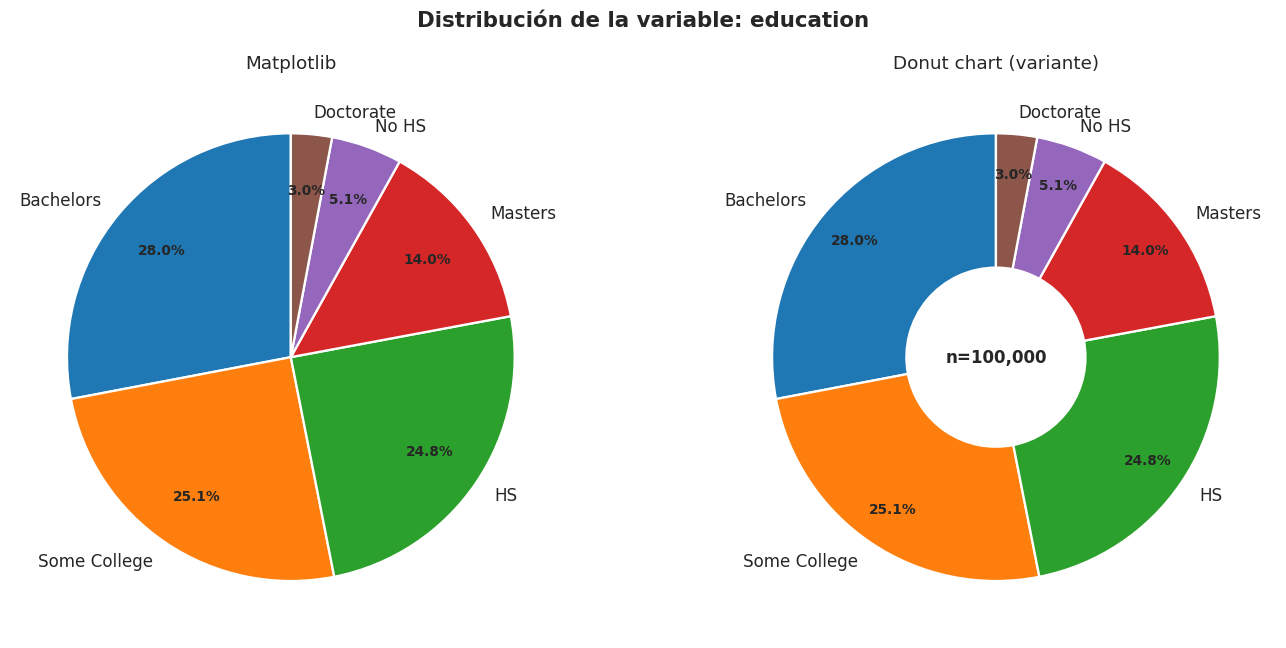


=== Distribución de 'education' ===

              Frecuencia     %
education                     
Bachelors          27996  28.0
Some College       25112  25.1
HS                 24827  24.8
Masters            13987  14.0
No HS               5120   5.1
Doctorate           2958   3.0


In [6]:

# 2D — Gráfico de torta de la variable educación

def encontrar_col(df, candidatos):
    for c in candidatos:
        if c in df.columns:
            return c
    raise KeyError(f"Ninguna de estas columnas existe: {candidatos}. Columnas disponibles: {list(df.columns)}")

col_edu = encontrar_col(df, ['education', 'Education', 'education_level', 'EducationLevel'])
print(f"Columna usada: '{col_edu}'")

conteo  = df[col_edu].value_counts().sort_values(ascending=False)
labels  = conteo.index.astype(str).tolist()
valores = conteo.values
colores = sns.color_palette('tab10', len(conteo))

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f'Distribución de la variable: {col_edu}', fontsize=14, fontweight='bold')

# ── 🔵 Matplotlib — pie estándar ────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    valores,
    labels=labels,
    autopct='%1.1f%%',
    colors=colores,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(linewidth=1.5, edgecolor='white')
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

axes[0].set_title('Matplotlib', fontsize=12)

# ── 🟠 Seaborn / Matplotlib — donut chart ──────────────────────────
wedges2, texts2, autotexts2 = axes[1].pie(
    valores,
    labels=labels,
    autopct='%1.1f%%',
    colors=colores,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.6, linewidth=1.5, edgecolor='white')   # donut
)
for at in autotexts2:
    at.set_fontsize(9)
    at.set_fontweight('bold')

# Texto central del donut
axes[1].text(0, 0, f'n={df[col_edu].notna().sum():,}',
             ha='center', va='center', fontsize=11, fontweight='bold')
axes[1].set_title('Donut chart (variante)', fontsize=12)

plt.tight_layout()
plt.show()

# ── Tabla de frecuencias ────────────────────────────────────────────
pct = conteo / conteo.sum() * 100
tabla = pd.DataFrame({'Frecuencia': conteo, '%': pct.round(1)})
print(f"\n=== Distribución de '{col_edu}' ===\n")
print(tabla.to_string())


  - 2 E) Gráfico de barra apiladas para employment_status según is_high_risk (cada barra suma 100%)

Columnas usadas → filas: 'employment_status' | grupos: 'is_high_risk'


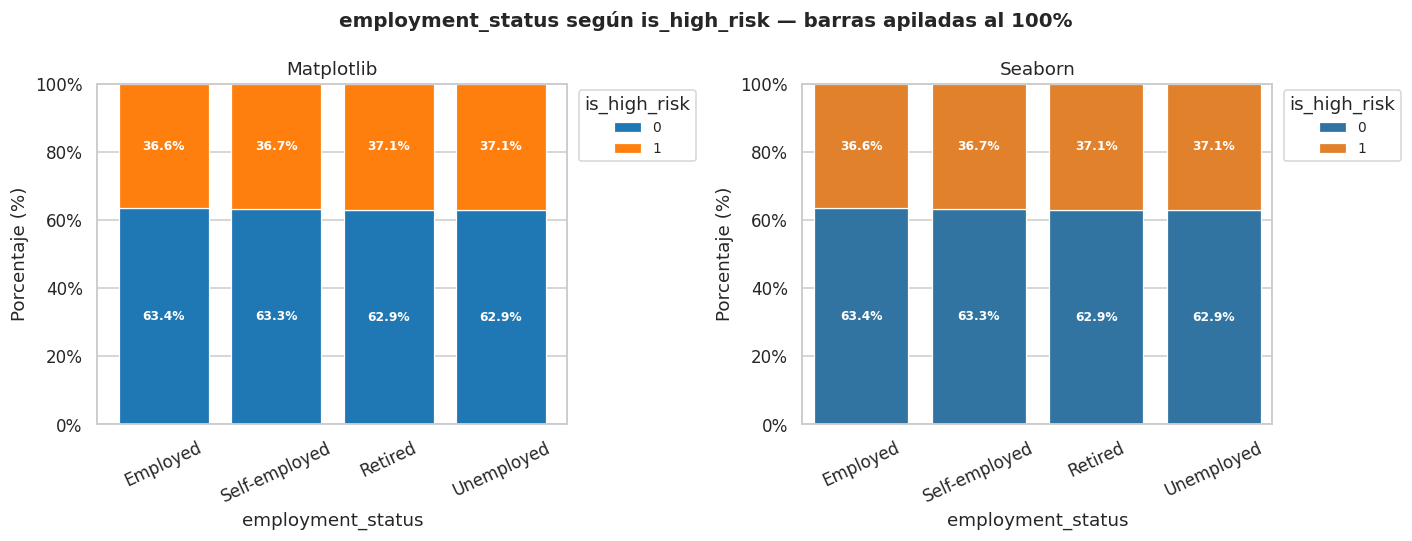


=== Frecuencias absolutas: employment_status × is_high_risk ===

is_high_risk           0      1   Total
employment_status                      
Employed           35036  20233   55269
Retired            12496   7368   19864
Self-employed       7548   4380   11928
Unemployed          8139   4800   12939
Total              63219  36781  100000

=== Porcentajes por fila (%) ===

is_high_risk          0     1
employment_status            
Employed           63.4  36.6
Self-employed      63.3  36.7
Retired            62.9  37.1
Unemployed         62.9  37.1


In [7]:

# 2E — Barras apiladas al 100%: employment_status según is_high_risk

def encontrar_col(df, candidatos):
    for c in candidatos:
        if c in df.columns:
            return c
    raise KeyError(f"Ninguna de estas columnas existe: {candidatos}. Columnas disponibles: {list(df.columns)}")

col_emp  = encontrar_col(df, ['employment_status', 'EmploymentStatus', 'employment'])
col_risk = encontrar_col(df, ['is_high_risk', 'IsHighRisk', 'high_risk', 'HighRisk'])
print(f"Columnas usadas → filas: '{col_emp}' | grupos: '{col_risk}'")

# Tabla de contingencia normalizada por fila (cada fila suma 100%)
tabla_pct = pd.crosstab(df[col_emp], df[col_risk], normalize='index') * 100

# Ordenar por el porcentaje de la primera categoría (descendente)
tabla_pct = tabla_pct.sort_values(tabla_pct.columns[0], ascending=False)

# Mantener los valores originales (pueden ser bool/int) para indexar el DataFrame
categorias_risk = tabla_pct.columns.tolist()
# Etiquetas de texto para leyendas y gráficos
etiquetas_risk  = [str(c) for c in categorias_risk]
n_cats          = len(categorias_risk)
colores         = sns.color_palette('tab10', n_cats)
x_labels        = tabla_pct.index.astype(str).tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{col_emp} según {col_risk} — barras apiladas al 100%',
             fontsize=13, fontweight='bold')

# ── 🔵 Matplotlib ──────────────────────────────────────────────────
bottom = np.zeros(len(tabla_pct))
for cat, etiq, color in zip(categorias_risk, etiquetas_risk, colores):
    vals = tabla_pct[cat].values
    bars = axes[0].bar(x_labels, vals, bottom=bottom,
                       color=color, label=etiq, edgecolor='white', linewidth=0.8)
    for bar, val, bot in zip(bars, vals, bottom):
        if val >= 5:
            axes[0].text(bar.get_x() + bar.get_width() / 2,
                         bot + val / 2,
                         f'{val:.1f}%',
                         ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Porcentaje (%)')
axes[0].set_xlabel(col_emp)
axes[0].set_title('Matplotlib')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(title=col_risk, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# ── 🟠 Seaborn (sobre Matplotlib) ─────────────────────────────────
bottom2 = np.zeros(len(tabla_pct))
for cat, etiq, color in zip(categorias_risk, etiquetas_risk, colores):
    vals = tabla_pct[cat].values
    sns.barplot(x=x_labels, y=vals, bottom=bottom2,
                color=color, label=etiq, ax=axes[1],
                edgecolor='white', linewidth=0.8)
    for xi, (val, bot) in enumerate(zip(vals, bottom2)):
        if val >= 5:
            axes[1].text(xi, bot + val / 2,
                         f'{val:.1f}%',
                         ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom2 += vals

axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xlabel(col_emp)
axes[1].set_title('Seaborn')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title=col_risk, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.show()

# ── Tabla resumen ───────────────────────────────────────────────────
tabla_abs = pd.crosstab(df[col_emp], df[col_risk], margins=True, margins_name='Total')
print(f"\n=== Frecuencias absolutas: {col_emp} × {col_risk} ===\n")
print(tabla_abs.to_string())

print(f"\n=== Porcentajes por fila (%) ===\n")
print(tabla_pct.round(1).to_string())
